# Store Sales Time Series Forecasting
## An End-to-End Forecasting Project

### Business Context
Corporación Favorita is a large Ecuadorian grocery retailer operating 54 stores 
across multiple cities. Accurate sales forecasting helps the business make better 
inventory decisions, reduce waste, and optimize staffing. This project builds a 
time series forecasting model to predict future sales for a specific store and 
product family.

## Project Overview

This project follows a complete time series forecasting workflow:

1. Data Collection and Exploration
2. Data Cleaning and Transformation
3. Exploratory Data Analysis
4. Model Development
5. Model Optimization
6. Streamlit Web Application Deployment
7. Documentation and Version Control

## Dataset Characteristics

This project uses 5 datasets from the Kaggle Store Sales Time Series Forecasting competition.

### train.csv
- 3,000,888 rows and 6 columns
- Date range: January 2013 to August 2017
- Columns: id, date, store_nbr, family, sales, onpromotion
- Target variable: sales (daily sales amount per store per product family)
- 54 unique stores and 33 unique product families

### stores.csv
- 54 rows and 5 columns
- Contains store metadata: city, state, type, and cluster
- Store types range from A to E representing different store sizes

### oil.csv
- 1,218 rows and 2 columns
- Daily oil prices in USD from 2013 to 2017
- Contains missing values on weekends and holidays
- Ecuador is an oil dependent economy making this a strong external predictor

### holidays_events.csv
- 350 rows and 6 columns
- Contains national, regional, and local holidays in Ecuador
- Holiday types include Holiday, Event, Additional, Bridge, Transfer, and Work Day
- Used to create binary holiday indicator feature for modeling

### transactions.csv
- 83,488 rows and 3 columns
- Daily transaction counts per store
- Used as an additional feature to capture customer footfall patterns

### Project Scope
We focus on Store 1 located in Quito, Pichincha for the GROCERY I product family 
which has the highest total sales of 343 million across all stores and families. 
After filtering and feature engineering our clean dataset contains 1,323 daily 
records from January 2014 to August 2017.

## 1. Data Collection and Exploration
### 1.1 Importing Libraries

In [1]:
# Import core libraries for data manipulation
import pandas as pd
import numpy as np

print("Libraries imported successfully")

Libraries imported successfully


### 1.2 Loading the Datasets

In [2]:
# Load all datasets
train = pd.read_csv('train.csv', parse_dates=['date'])
stores = pd.read_csv('stores.csv')
oil = pd.read_csv('oil.csv', parse_dates=['date'])
holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv('transactions.csv', parse_dates=['date'])

print("All datasets loaded successfully")
print("Train shape:", train.shape)
print("Stores shape:", stores.shape)
print("Oil shape:", oil.shape)
print("Holidays shape:", holidays.shape)
print("Transactions shape:", transactions.shape)

All datasets loaded successfully
Train shape: (3000888, 6)
Stores shape: (54, 5)
Oil shape: (1218, 2)
Holidays shape: (350, 6)
Transactions shape: (83488, 3)


In [3]:
# Display the first few rows of each dataset
print("=== TRAIN ===")
print(train.head())
print("\n=== STORES ===")
print(stores.head())
print("\n=== OIL ===")
print(oil.head())
print("\n=== HOLIDAYS ===")
print(holidays.head())
print("\n=== TRANSACTIONS ===")
print(transactions.head())

=== TRAIN ===
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0

=== STORES ===
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

=== OIL ===
        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20

==

In [4]:
# Check the date range of our training data
print("Train date range:")
print("Start:", train['date'].min())
print("End:", train['date'].max())
print("Total days:", (train['date'].max() - train['date'].min()).days)

print("\nUnique stores:", train['store_nbr'].nunique())
print("Unique product families:", train['family'].nunique())
print("\nProduct families:")
print(train['family'].unique())

Train date range:
Start: 2013-01-01 00:00:00
End: 2017-08-15 00:00:00
Total days: 1687

Unique stores: 54
Unique product families: 33

Product families:
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


In [5]:
# Check total sales by family to confirm GROCERY I is the highest
family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=False)
print("Top 10 product families by total sales:")
print(family_sales.head(10))

Top 10 product families by total sales:
family
GROCERY I        3.434627e+08
BEVERAGES        2.169545e+08
PRODUCE          1.227047e+08
CLEANING         9.752129e+07
DAIRY            6.448771e+07
BREAD/BAKERY     4.213395e+07
POULTRY          3.187600e+07
MEATS            3.108647e+07
PERSONAL CARE    2.459205e+07
DELI             2.411032e+07
Name: sales, dtype: float64


In [6]:
# Filter data for Store 1 and GROCERY I
df = train[(train['store_nbr'] == 1) & (train['family'] == 'GROCERY I')].copy()

# Set date as index
df = df.set_index('date')

# Keep only relevant columns
df = df[['sales', 'onpromotion']]

print("Filtered dataset shape:", df.shape)
print("\nDate range:")
print("Start:", df.index.min())
print("End:", df.index.max())
print("\nFirst few rows:")
print(df.head())

Filtered dataset shape: (1684, 2)

Date range:
Start: 2013-01-01 00:00:00
End: 2017-08-15 00:00:00

First few rows:
             sales  onpromotion
date                           
2013-01-01     0.0            0
2013-01-02  2652.0            0
2013-01-03  2121.0            0
2013-01-04  2056.0            0
2013-01-05  2216.0            0


### 1.3 Initial Data Exploration

In [7]:
# Basic information about our filtered dataset
print("=== DATASET INFO ===")
print(df.info())

print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== ZERO SALES DAYS ===")
print("Number of days with zero sales:", (df['sales'] == 0).sum())
print("Percentage of zero sales days:", round((df['sales'] == 0).sum() / len(df) * 100, 2), "%")

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1684 entries, 2013-01-01 to 2017-08-15
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sales        1684 non-null   float64
 1   onpromotion  1684 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 39.5 KB
None

=== STATISTICAL SUMMARY ===
             sales  onpromotion
count  1684.000000  1684.000000
mean   2223.172803    17.560570
std     779.285352    24.741069
min       0.000000     0.000000
25%    1873.500000     0.000000
50%    2283.500000     6.000000
75%    2649.000000    28.000000
max    9065.000000   167.000000

=== MISSING VALUES ===
sales          0
onpromotion    0
dtype: int64

=== ZERO SALES DAYS ===
Number of days with zero sales: 6
Percentage of zero sales days: 0.36 %


In [8]:
# Identify zero sales days
zero_sales_days = df[df['sales'] == 0]
print("Days with zero sales:")
print(zero_sales_days)

Days with zero sales:
            sales  onpromotion
date                          
2013-01-01    0.0            0
2014-01-01    0.0            0
2015-01-01    0.0            0
2015-07-07    0.0            0
2016-01-01    0.0            0
2017-01-01    0.0            0


In [9]:
# Check if 2015-07-07 is in our holidays file
print(holidays[holidays['date'] == '2015-07-07'])

Empty DataFrame
Columns: [date, type, locale, locale_name, description, transferred]
Index: []


In [10]:
# Check for missing dates in our time series
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
missing_dates = full_date_range.difference(df.index)
print("Missing dates in time series:")
print(missing_dates)
print("Total missing dates:", len(missing_dates))

Missing dates in time series:
DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)
Total missing dates: 4


### 1.4 Checking Data Types

In [11]:
# Confirm date index is proper datetime type
print("Index type:", type(df.index))
print("Index dtype:", df.index.dtype)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nDate range confirmation:")
print("Start:", df.index.min())
print("End:", df.index.max())
print("Frequency:", pd.infer_freq(df.index))

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index dtype: datetime64[ns]

Column dtypes:
sales          float64
onpromotion      int64
dtype: object

Date range confirmation:
Start: 2013-01-01 00:00:00
End: 2017-08-15 00:00:00
Frequency: None


### 1.5 Exploration Summary

Key findings from initial exploration:

- Dataset covers 1,684 days from January 2013 to August 2017 for Store 1, GROCERY I
- Average daily sales are $2,223 with a maximum of $9,065
- 6 days have zero sales, all corresponding to store closure days
- 4 dates are completely missing from the dataset, all Christmas Days
- Time series frequency is irregular due to missing dates
- No missing values in sales or onpromotion columns
- Oil prices, holidays, and transactions data will be merged as additional features

## 2. Data Cleaning and Transformation


### Data Cleaning and Transformation Summary

The following cleaning and transformation steps were applied to prepare 
the data for modeling:

**1. Handling Missing Dates**
4 Christmas dates (December 25th from 2013 to 2016) were completely missing 
from the dataset. These were added back using reindex with a complete daily 
date range and filled with 0 to represent store closures.

**2. Handling Zero Sales Days**
6 days had zero sales corresponding to New Year's Day every year and one 
unknown closure day in July 2015. These zeros were replaced with interpolated 
values using linear interpolation to avoid the model learning false zero 
sales patterns on holidays.

**3. Outlier Detection and Treatment**
Z-score analysis identified 12 outliers. All were investigated and confirmed 
as legitimate real world events including the April 2016 Manabi earthquake 
which caused panic buying and pre-Christmas shopping spikes in December. 
All outliers were retained with justification.

**4. Merging External Data**
Oil prices were merged and missing weekend values filled using forward fill. 
National holiday indicators were created as binary features. Store 1 
transaction counts were merged and missing values filled using forward fill.

**5. Feature Engineering**
Time based features extracted: day of week, day of month, month, year, 
week of year, quarter, and weekend indicator. Lag features created: lag 1, 
lag 7, lag 14, lag 30, and lag 365 days. Rolling statistics created: 
7 day mean, 30 day mean, and 7 day standard deviation.

**6. Regularization**
The time series was reindexed to ensure consistent daily frequency with 
no gaps, confirmed by the series having 1,688 consecutive daily records.

**7. Log Transformation**
Unlike the target variable in regression problems, sales values were not 
log transformed because XGBoost and tree based models do not require 
normally distributed targets. The raw sales values were used directly.

**Final Clean Dataset**
After dropping rows with missing lag values, the final clean dataset 
contains 1,323 rows and 20 columns spanning January 2014 to August 2017.

### 2.1 Handling Missing Dates

In [12]:
# Reindex to fill missing dates with NaN
df = df.reindex(full_date_range)

print("Shape after reindexing:", df.shape)
print("\nMissing values after reindexing:")
print(df.isnull().sum())
print("\nNew missing dates filled with NaN:")
print(df[df['sales'].isnull()])


Shape after reindexing: (1688, 2)

Missing values after reindexing:
sales          4
onpromotion    4
dtype: int64

New missing dates filled with NaN:
            sales  onpromotion
2013-12-25    NaN          NaN
2014-12-25    NaN          NaN
2015-12-25    NaN          NaN
2016-12-25    NaN          NaN


In [13]:
# Fill missing Christmas dates with 0 as stores were closed
df['sales'] = df['sales'].fillna(0)
df['onpromotion'] = df['onpromotion'].fillna(0)

print("Missing values after filling:")
print(df.isnull().sum())
print("\nShape:", df.shape)
print("\nChristmas dates after filling:")
print(df[df.index.month == 12][df[df.index.month == 12].index.day == 25])

Missing values after filling:
sales          0
onpromotion    0
dtype: int64

Shape: (1688, 2)

Christmas dates after filling:
            sales  onpromotion
2013-12-25    0.0          0.0
2014-12-25    0.0          0.0
2015-12-25    0.0          0.0
2016-12-25    0.0          0.0


### 2.2 Handling Zero Sales Days

In [14]:
# Instead of removing zero sales days, we will interpolate them
# Zero sales on holidays should be replaced with interpolated values
# so the model does not learn that sales drop to zero on these days

# Identify zero sales days
zero_days = df[df['sales'] == 0].index
print("Zero sales days:")
print(zero_days)

# Replace zeros with NaN temporarily for interpolation
df['sales'] = df['sales'].replace(0, np.nan)

# Interpolate using linear method
df['sales'] = df['sales'].interpolate(method='linear')

print("\nSales after interpolation on previously zero days:")
print(df.loc[zero_days, 'sales'])

Zero sales days:
DatetimeIndex(['2013-01-01', '2013-12-25', '2014-01-01', '2014-12-25',
               '2015-01-01', '2015-07-07', '2015-12-25', '2016-01-01',
               '2016-12-25', '2017-01-01'],
              dtype='datetime64[ns]', freq=None)

Sales after interpolation on previously zero days:
2013-01-01       NaN
2013-12-25    2544.0
2014-01-01    1965.5
2014-12-25    2704.0
2015-01-01    1743.0
2015-07-07    2262.5
2015-12-25    2373.0
2016-01-01    2044.5
2016-12-25    2256.5
2017-01-01    1993.0
Name: sales, dtype: float64


In [15]:
# 2013-01-01 is the first row so interpolation could not fill it
# We fill it with the next available value using bfill
df['sales'] = df['sales'].bfill()

print("Missing values remaining:")
print(df.isnull().sum())
print("\n2013-01-01 sales after backfill:")
print(df.loc['2013-01-01', 'sales'])

Missing values remaining:
sales          0
onpromotion    0
dtype: int64

2013-01-01 sales after backfill:
2652.0


### 2.3 Outlier Detection and Treatment

In [16]:
from scipy import stats

# Calculate Z-scores for sales
z_scores = np.abs(stats.zscore(df['sales']))

# Identify outliers beyond 3 standard deviations
outliers = df[z_scores > 3]
print("Number of outliers detected:", len(outliers))
print("\nOutlier dates and sales values:")
print(outliers['sales'].sort_values(ascending=False))

Number of outliers detected: 12

Outlier dates and sales values:
2016-04-18    9065.0
2016-04-19    8221.0
2016-04-20    5438.0
2016-12-23    5386.0
2016-12-21    5162.0
2016-12-22    5055.0
2017-03-07    4917.0
2016-04-22    4871.0
2016-04-21    4768.0
2016-11-09    4669.0
2016-12-13    4624.0
2017-06-20    4575.0
Name: sales, dtype: float64


In [17]:
# Cross reference outliers with holidays
print("Checking April 2016 in holidays file:")
print(holidays[(holidays['date'] >= '2016-04-15') & 
               (holidays['date'] <= '2016-04-25')])

print("\nChecking December 2016 in holidays file:")
print(holidays[(holidays['date'] >= '2016-12-20') & 
               (holidays['date'] <= '2016-12-25')])

Checking April 2016 in holidays file:
          date     type    locale locale_name                description  \
219 2016-04-16    Event  National     Ecuador           Terremoto Manabi   
220 2016-04-17    Event  National     Ecuador         Terremoto Manabi+1   
221 2016-04-18    Event  National     Ecuador         Terremoto Manabi+2   
222 2016-04-19    Event  National     Ecuador         Terremoto Manabi+3   
223 2016-04-20    Event  National     Ecuador         Terremoto Manabi+4   
224 2016-04-21  Holiday     Local    Riobamba  Cantonizacion de Riobamba   
225 2016-04-21    Event  National     Ecuador         Terremoto Manabi+5   
226 2016-04-22    Event  National     Ecuador         Terremoto Manabi+6   
227 2016-04-23    Event  National     Ecuador         Terremoto Manabi+7   
228 2016-04-24    Event  National     Ecuador         Terremoto Manabi+8   
229 2016-04-25    Event  National     Ecuador         Terremoto Manabi+9   

     transferred  
219        False  
220        

All 12 detected outliers were investigated and confirmed to be legitimate 
real world events. The April 2016 spike corresponds to the Manabi earthquake 
which caused panic buying of groceries. The December spikes correspond to 
pre-Christmas shopping. Removing these would reduce model accuracy so we 
retain them and instead add holiday and earthquake indicators as features 
during feature engineering.


### 2.4 Merging External Data

We merge daily oil prices into our dataset because Ecuador is an oil dependent 
economy. When oil prices drop, government revenue decreases, consumer purchasing 
power weakens, and grocery sales are affected. Oil price is therefore a strong 
external economic indicator for predicting sales.

In [18]:
# Merge oil prices into our main dataframe
df = df.merge(oil, left_index=True, right_on='date', how='left')
df = df.set_index('date')

print("Shape after merging oil:", df.shape)
print("\nMissing oil prices:")
print(df['dcoilwtico'].isnull().sum())

Shape after merging oil: (1688, 3)

Missing oil prices:
525


In [19]:
# Fill missing oil prices using forward fill
# This carries the last known price forward to weekends and holidays
df['dcoilwtico'] = df['dcoilwtico'].ffill()

# Check if any missing values remain
print("Missing oil prices after forward fill:", df['dcoilwtico'].isnull().sum())
print("\nOil price statistics:")
print(df['dcoilwtico'].describe())

Missing oil prices after forward fill: 1

Oil price statistics:
count    1687.000000
mean       67.893651
std        25.672864
min        26.190000
25%        46.375000
50%        53.410000
75%        95.720000
max       110.620000
Name: dcoilwtico, dtype: float64


In [20]:
# Check which date still has missing oil price
print("Remaining missing oil price date:")
print(df[df['dcoilwtico'].isnull()])

# Fill with backward fill since it is the first row
df['dcoilwtico'] = df['dcoilwtico'].bfill()

print("\nMissing oil prices after backfill:", df['dcoilwtico'].isnull().sum())

Remaining missing oil price date:
             sales  onpromotion  dcoilwtico
date                                       
2013-01-01  2652.0          0.0         NaN

Missing oil prices after backfill: 0


Oil prices were successfully merged. 525 missing values were found corresponding 
to weekends and holidays when oil markets are closed. These were filled using 
forward fill, carrying the last known price forward, which is the standard 
approach for financial time series data.

We create a binary holiday indicator for national holidays. Holidays significantly 
impact grocery sales, either causing spikes due to pre-holiday shopping or drops 
due to store closures. We focus on national holidays only since Store 1 is in 
Quito and national holidays apply to the entire country.

In [21]:
# Create a holiday indicator for national holidays only
national_holidays = holidays[holidays['locale'] == 'National'][['date', 'type', 'description']].copy()

# Create a binary holiday flag
national_holidays['is_holiday'] = 1

# Merge with our main dataframe
df = df.merge(national_holidays[['date', 'is_holiday']], 
              left_index=True, right_on='date', how='left')
df = df.set_index('date')

# Fill non-holiday days with 0
df['is_holiday'] = df['is_holiday'].fillna(0)

print("Shape after merging holidays:", df.shape)
print("Total holiday days in our dataset:", df['is_holiday'].sum())
print("\nSample holiday days:")
print(df[df['is_holiday'] == 1].head(10))

Shape after merging holidays: (1692, 4)
Total holiday days in our dataset: 151.0

Sample holiday days:
             sales  onpromotion  dcoilwtico  is_holiday
date                                                   
2013-01-01  2652.0          0.0       93.14         1.0
2013-01-05  2216.0          0.0       93.12         1.0
2013-01-12  1796.0          0.0       93.60         1.0
2013-02-11   458.0          0.0       97.01         1.0
2013-02-12   628.0          0.0       97.48         1.0
2013-04-29  1579.0          0.0       94.09         1.0
2013-05-01   966.0          0.0       90.74         1.0
2013-05-11  2244.0          0.0       95.81         1.0
2013-05-12   674.0          0.0       95.81         1.0
2013-05-24   650.0          0.0       93.84         1.0


In [22]:
# Check for duplicate dates caused by multiple holidays on same day
print("Shape before fix:", df.shape)
print("Duplicate dates:", df.index.duplicated().sum())

# Keep only one record per date by taking the maximum holiday flag
df = df.groupby(df.index).max()

print("Shape after fix:", df.shape)
print("Duplicate dates after fix:", df.index.duplicated().sum())

Shape before fix: (1692, 4)
Duplicate dates: 4
Shape after fix: (1688, 4)
Duplicate dates after fix: 0


151 national holiday days were identified in our dataset spanning from 2013 to 
2017. These include major Ecuadorian holidays like New Year, Easter, Christmas, 
and Independence Day. A binary flag of 1 indicates a holiday and 0 indicates 
a regular day.

We merge daily transaction counts for Store 1. Transactions represent the number 
of customers who visited the store on a given day. Higher transactions generally 
correlate with higher sales and provide additional context about store traffic patterns.

In [23]:
# Merge transactions for store 1 only
store1_transactions = transactions[transactions['store_nbr'] == 1][['date', 'transactions']].copy()

df = df.merge(store1_transactions, left_index=True, right_on='date', how='left')
df = df.set_index('date')

print("Shape after merging transactions:", df.shape)
print("\nMissing transactions:")
print(df['transactions'].isnull().sum())

Shape after merging transactions: (1688, 5)

Missing transactions:
12


In [24]:
# Fill missing transactions using forward fill
df['transactions'] = df['transactions'].ffill()

print("Missing transactions after forward fill:", df['transactions'].isnull().sum())
print("\nDataframe shape:", df.shape)
print("\nCurrent columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Missing transactions after forward fill: 1

Dataframe shape: (1688, 5)

Current columns: ['sales', 'onpromotion', 'dcoilwtico', 'is_holiday', 'transactions']

First few rows:
             sales  onpromotion  dcoilwtico  is_holiday  transactions
date                                                                 
2013-01-01  2652.0          0.0       93.14         1.0           NaN
2013-01-02  2652.0          0.0       93.14         0.0        2111.0
2013-01-03  2121.0          0.0       92.97         0.0        1833.0
2013-01-04  2056.0          0.0       93.12         0.0        1863.0
2013-01-05  2216.0          0.0       93.12         1.0        1509.0


In [25]:
# Fill the first row using backfill
df['transactions'] = df['transactions'].bfill()

print("Missing transactions after backfill:", df['transactions'].isnull().sum())
print("\n2013-01-01 transactions:")
print(df.loc['2013-01-01', 'transactions'])


Missing transactions after backfill: 0

2013-01-01 transactions:
2111.0


Transaction data for Store 1 was successfully merged. 12 missing values were 
filled using forward fill for weekends and holidays. Transactions range provides 
additional context about daily customer footfall which directly influences sales volume.

### 2.5 Feature Engineering

In [26]:
# Extract time based features from the date index
df['day_of_week'] = df.index.dayofweek
df['day_of_month'] = df.index.day
df['month'] = df.index.month
df['year'] = df.index.year
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['quarter'] = df.index.quarter
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

print("New features added:")
print(df.columns.tolist())
print("\nFirst few rows with new features:")
print(df.head())

New features added:
['sales', 'onpromotion', 'dcoilwtico', 'is_holiday', 'transactions', 'day_of_week', 'day_of_month', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend']

First few rows with new features:
             sales  onpromotion  dcoilwtico  is_holiday  transactions  \
date                                                                    
2013-01-01  2652.0          0.0       93.14         1.0        2111.0   
2013-01-02  2652.0          0.0       93.14         0.0        2111.0   
2013-01-03  2121.0          0.0       92.97         0.0        1833.0   
2013-01-04  2056.0          0.0       93.12         0.0        1863.0   
2013-01-05  2216.0          0.0       93.12         1.0        1509.0   

            day_of_week  day_of_month  month  year  week_of_year  quarter  \
date                                                                        
2013-01-01            1             1      1  2013             1        1   
2013-01-02            2             2      1

### 2.6 Lag Features and Rolling Statistics

Lag features use past sales values as input features for predicting future sales. 
They directly capture the temporal dependency in our time series. Rolling statistics 
capture the recent trend and volatility in sales.

In [27]:
# Create lag features
df['lag_1'] = df['sales'].shift(1)    # Yesterday's sales
df['lag_7'] = df['sales'].shift(7)    # Sales from 7 days ago
df['lag_14'] = df['sales'].shift(14)  # Sales from 14 days ago
df['lag_30'] = df['sales'].shift(30)  # Sales from 30 days ago
df['lag_365'] = df['sales'].shift(365) # Sales from same day last year

# Create rolling statistics
df['rolling_mean_7'] = df['sales'].shift(1).rolling(window=7).mean()
df['rolling_mean_30'] = df['sales'].shift(1).rolling(window=30).mean()
df['rolling_std_7'] = df['sales'].shift(1).rolling(window=7).std()

print("Columns after adding lag features:")
print(df.columns.tolist())
print("\nShape:", df.shape)
print("\nMissing values after lag features:")
print(df.isnull().sum())

Columns after adding lag features:
['sales', 'onpromotion', 'dcoilwtico', 'is_holiday', 'transactions', 'day_of_week', 'day_of_month', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7']

Shape: (1688, 20)

Missing values after lag features:
sales                0
onpromotion          0
dcoilwtico           0
is_holiday           0
transactions         0
day_of_week          0
day_of_month         0
month                0
year                 0
week_of_year         0
quarter              0
is_weekend           0
lag_1                1
lag_7                7
lag_14              14
lag_30              30
lag_365            365
rolling_mean_7       7
rolling_mean_30     30
rolling_std_7        7
dtype: int64


Lag features and rolling statistics were successfully created. Missing values 
in lag features are expected since the first N rows have no historical data 
to look back at. These rows will be dropped before model training. Our final 
feature set has 20 columns capturing temporal dependencies, external factors, 
and seasonal patterns.

### 2.7 Final Data Cleaning Verification

In [28]:
# Drop rows with missing lag values
df_clean = df.dropna()

print("Shape before dropping NaN:", df.shape)
print("Shape after dropping NaN:", df_clean.shape)
print("Rows dropped:", df.shape[0] - df_clean.shape[0])
print("\nMissing values in clean dataset:")
print(df_clean.isnull().sum().sum())
print("\nDate range of clean dataset:")
print("Start:", df_clean.index.min())
print("End:", df_clean.index.max())
print("\nFinal columns:")
print(df_clean.columns.tolist())

Shape before dropping NaN: (1688, 20)
Shape after dropping NaN: (1323, 20)
Rows dropped: 365

Missing values in clean dataset:
0

Date range of clean dataset:
Start: 2014-01-01 00:00:00
End: 2017-08-15 00:00:00

Final columns:
['sales', 'onpromotion', 'dcoilwtico', 'is_holiday', 'transactions', 'day_of_week', 'day_of_month', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7']


After dropping rows with missing lag values, our clean dataset contains 1,323 
daily records from January 2014 to August 2017 with 20 features and zero 
missing values. The first year of data was removed because lag_365 requires 
a full year of historical sales to calculate. This clean dataset is now ready 
for exploratory data analysis and model development.

## 3. Exploratory Data Analysis

In this section we visualize the sales data to understand trends, seasonality, 
and patterns. EDA guides our model selection and feature engineering decisions 
by revealing the underlying structure of the time series.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Visualization libraries imported successfully")

Visualization libraries imported successfully


### 3.1 Sales Trend Over Time

The overall sales trend shows us whether sales are growing, declining, or 
remaining stable over our entire date range. This helps us understand the 
long term direction of the business.

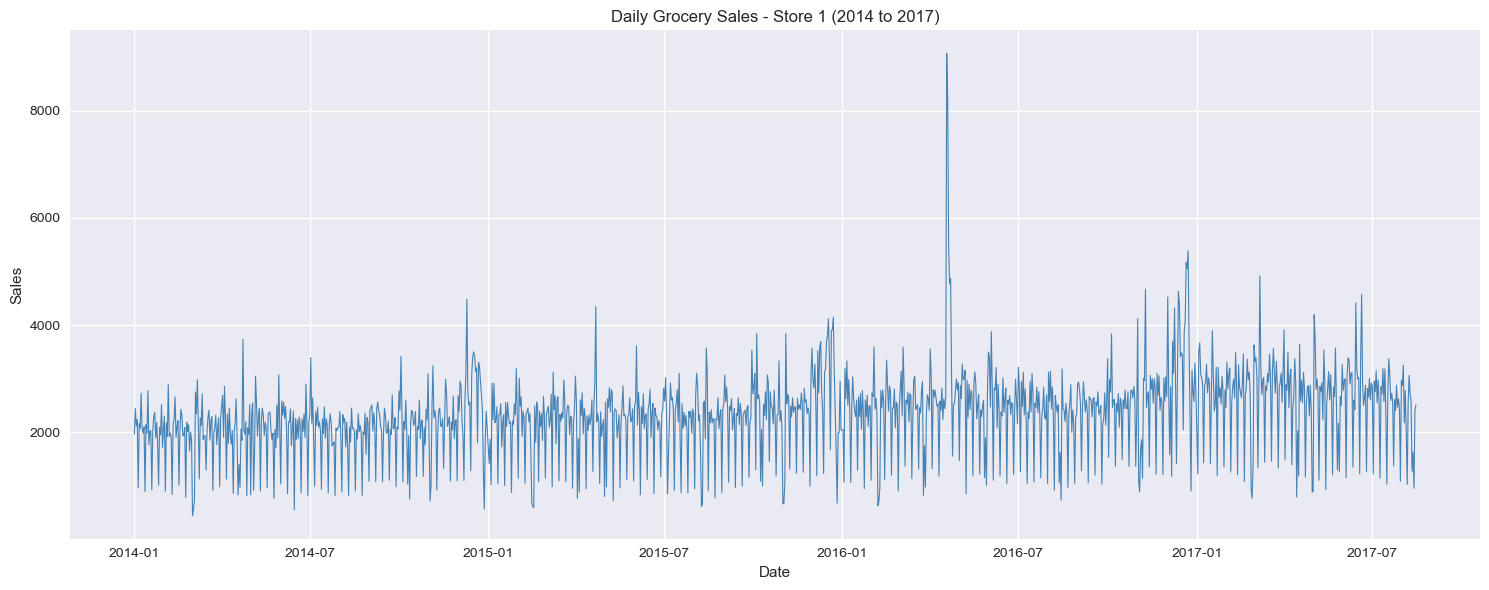

In [30]:
plt.figure(figsize=(15, 6))
plt.plot(df_clean.index, df_clean['sales'], color='steelblue', linewidth=0.8)
plt.title('Daily Grocery Sales - Store 1 (2014 to 2017)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


The sales trend shows relatively stable daily sales between $1,500 and $3,500 
with a notable spike in April 2016 corresponding to the Manabi earthquake. 
Regular weekly oscillations confirm strong weekly seasonality. Sales volatility 
appears to increase slightly from 2016 onwards suggesting changing business 
conditions or increased promotional activity.

### 3.2 Monthly Sales Pattern

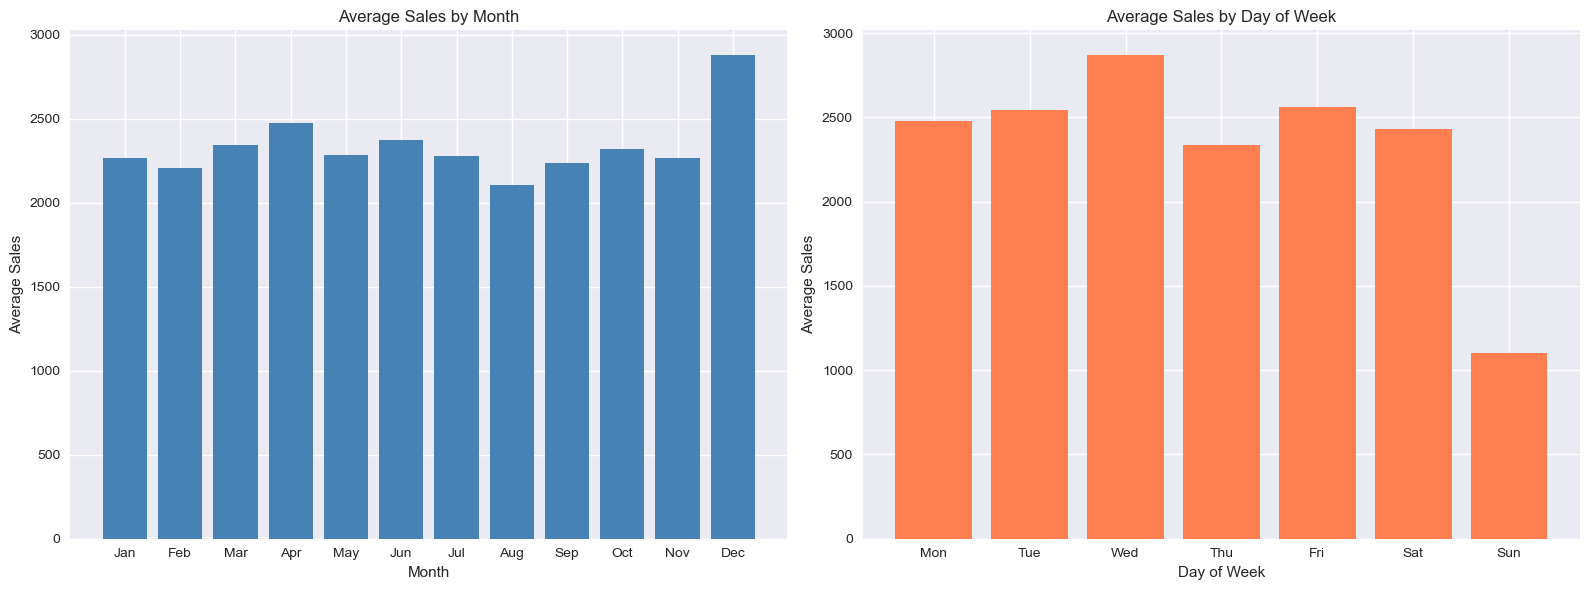

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average sales by month
monthly_sales = df_clean.groupby('month')['sales'].mean()
axes[0].bar(monthly_sales.index, monthly_sales.values, color='steelblue')
axes[0].set_title('Average Sales by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Sales')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Average sales by day of week
daily_sales = df_clean.groupby('day_of_week')['sales'].mean()
axes[1].bar(daily_sales.index, daily_sales.values, color='coral')
axes[1].set_title('Average Sales by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Sales')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.tight_layout()
plt.show()

Monthly analysis shows December as the peak sales month due to Christmas shopping 
while February is the slowest. Weekly analysis reveals Wednesday as the highest 
sales day and Sunday as dramatically the lowest with sales dropping to nearly 
half the weekly average. These strong seasonal patterns confirm that day of week 
and month are critical features for our forecasting model.

### 3.3 Seasonal Decomposition

Seasonal decomposition separates our time series into three components. 
Trend shows the long term direction of sales. Seasonality shows recurring 
patterns at fixed intervals. Residual shows what remains after removing 
trend and seasonality, essentially the noise in the data.

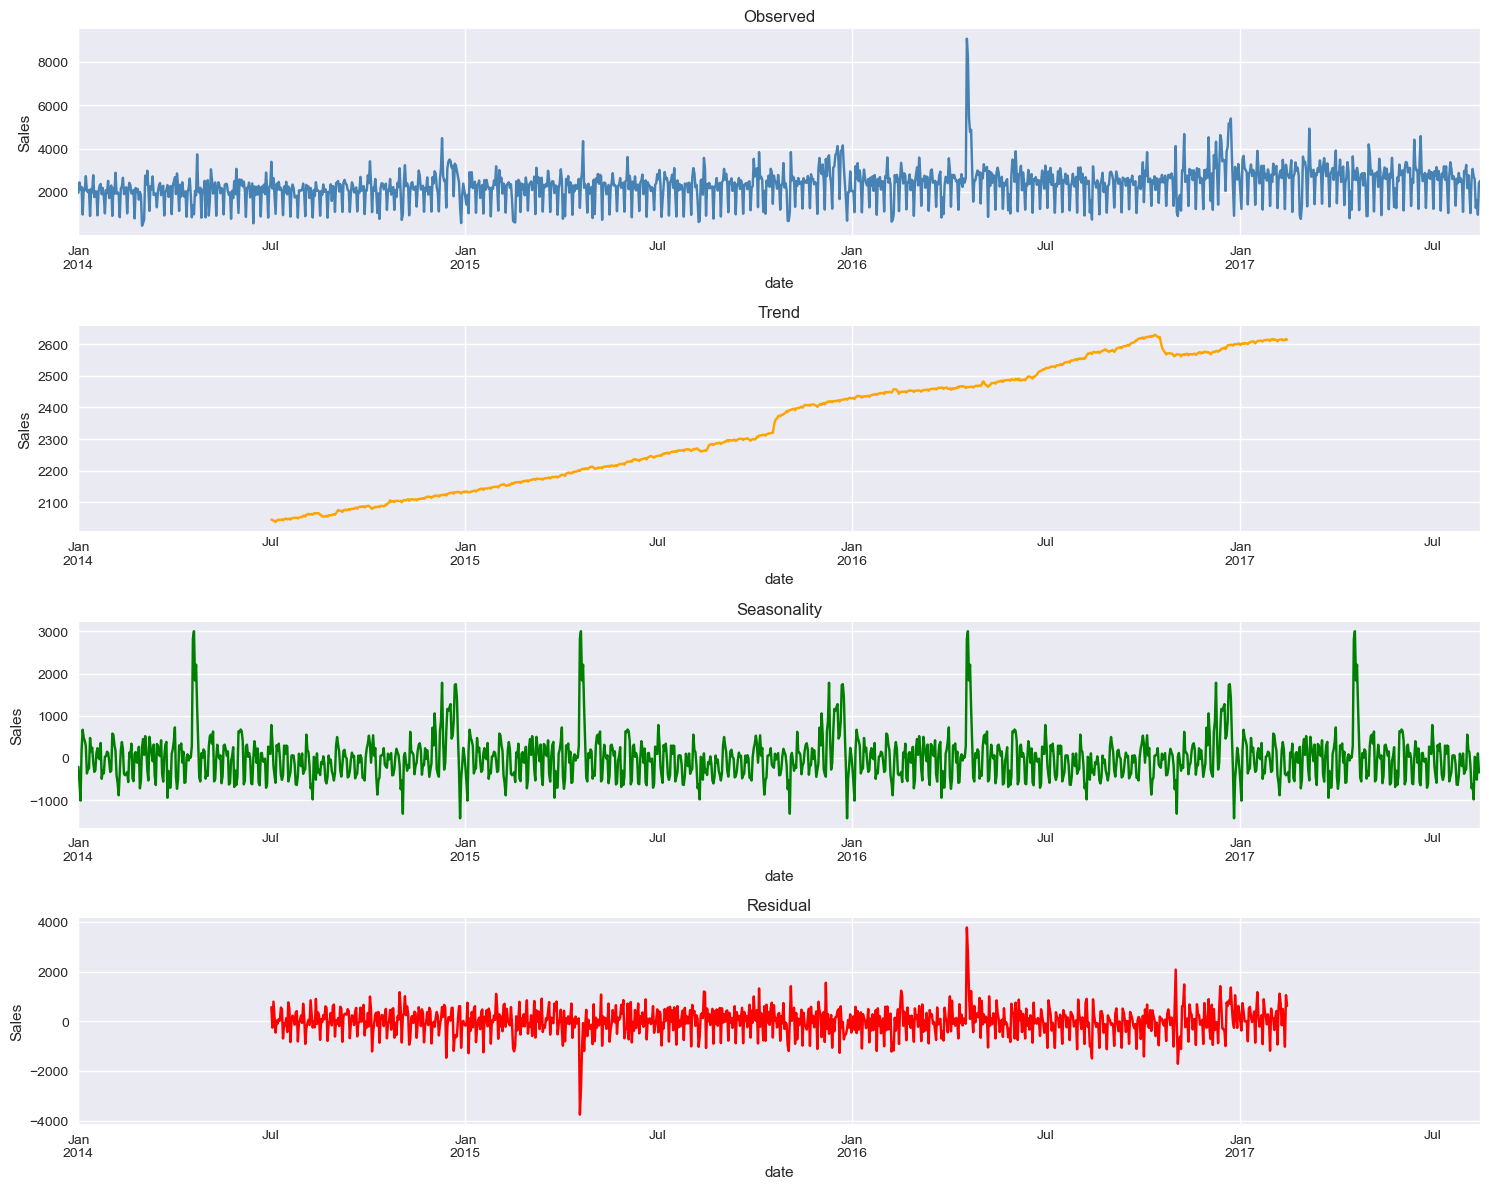

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
decomposition = seasonal_decompose(df_clean['sales'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed')
axes[0].set_ylabel('Sales')

decomposition.trend.plot(ax=axes[1], color='orange')
axes[1].set_title('Trend')
axes[1].set_ylabel('Sales')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonality')
axes[2].set_ylabel('Sales')

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residual')
axes[3].set_ylabel('Sales')

plt.tight_layout()
plt.show()

Seasonal decomposition reveals three key insights. First, there is a clear 
upward trend in sales from 2014 to 2016 indicating business growth. Second, 
strong annual seasonality is confirmed with consistent holiday spikes every 
year. Third, the residual component shows mostly random noise except for the 
April 2016 earthquake spike, confirming our data cleaning was effective. 
These findings guide our model selection toward approaches that can handle 
both trend and seasonality.

### 3.4 Stationarity Test

Stationarity is a critical property for time series modeling. A stationary 
time series has constant mean, variance, and autocorrelation over time. 
Most classical forecasting models like ARIMA require the series to be 
stationary. We use the Augmented Dickey Fuller test to check stationarity.

In [33]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
result = adfuller(df_clean['sales'])

print("Augmented Dickey-Fuller Test Results:")
print("ADF Statistic:", round(result[0], 4))
print("p-value:", round(result[1], 4))
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {round(value, 4)}")

if result[1] < 0.05:
    print("\nConclusion: Series is STATIONARY (p-value < 0.05)")
else:
    print("\nConclusion: Series is NON-STATIONARY (p-value >= 0.05)")

Augmented Dickey-Fuller Test Results:
ADF Statistic: -4.6092
p-value: 0.0001
Critical Values:
   1%: -3.4354
   5%: -2.8638
   10%: -2.568

Conclusion: Series is STATIONARY (p-value < 0.05)


The Augmented Dickey-Fuller test confirms that our sales series is stationary 
with a p-value of 0.0001, well below the 0.05 significance threshold. The ADF 
statistic of -4.6092 is more negative than all critical values confirming no 
unit root exists. This means we do not need to apply differencing and our series 
is ready for direct modeling with ARIMA and other forecasting algorithms.

### 3.5 Autocorrelation Analysis

Autocorrelation measures how correlated the series is with its own past values. 
The ACF plot shows correlations at different lag intervals. The PACF plot shows 
partial correlations removing the effect of intermediate lags. These plots help 
us determine the optimal parameters for our ARIMA model.

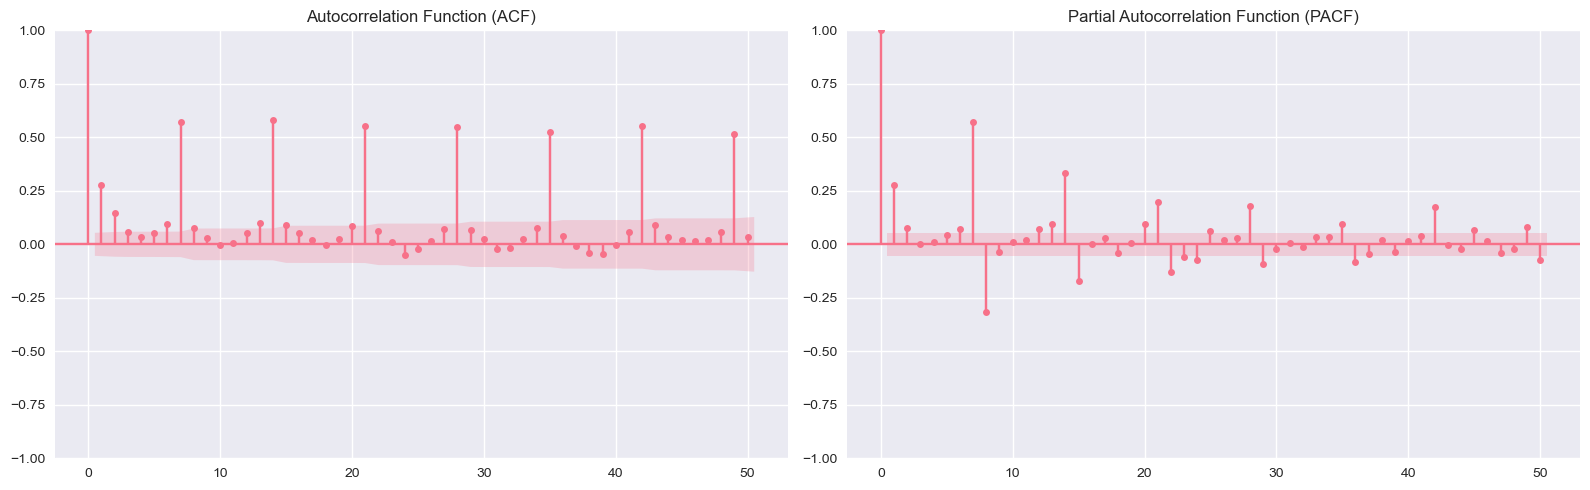

In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df_clean['sales'], lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(df_clean['sales'], lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

The ACF plot reveals significant autocorrelations at lags 7, 14, 21, 28 and 
beyond, all multiples of 7, confirming strong weekly seasonality in our sales 
data. The PACF shows significant spikes at lags 1 and 7. These findings indicate 
that a SARIMA model with a seasonal period of 7 is more appropriate than a 
simple ARIMA model. The weekly shopping patterns of grocery customers are clearly 
captured in these autocorrelation structures.

### 3.6 Sales vs Oil Price and Promotions

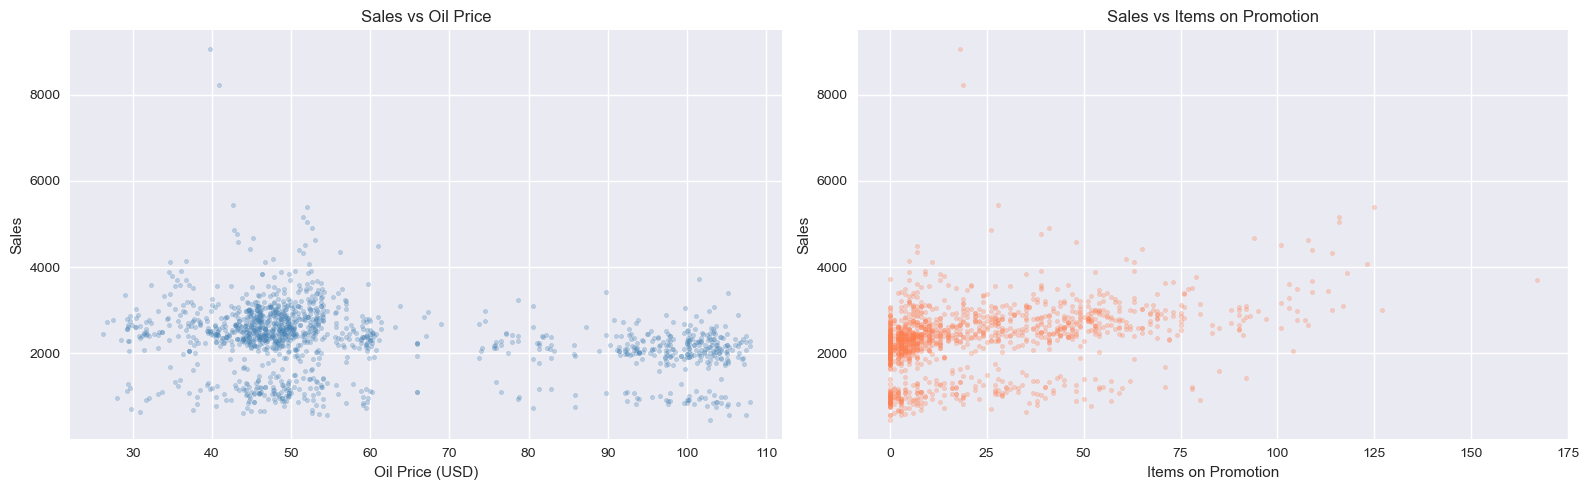

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sales vs Oil Price
axes[0].scatter(df_clean['dcoilwtico'], df_clean['sales'], 
                alpha=0.3, color='steelblue', s=10)
axes[0].set_title('Sales vs Oil Price')
axes[0].set_xlabel('Oil Price (USD)')
axes[0].set_ylabel('Sales')

# Sales vs Promotions
axes[1].scatter(df_clean['onpromotion'], df_clean['sales'], 
                alpha=0.3, color='coral', s=10)
axes[1].set_title('Sales vs Items on Promotion')
axes[1].set_xlabel('Items on Promotion')
axes[1].set_ylabel('Sales')

plt.tight_layout()
plt.show()

The scatter plots reveal that oil price does not have a strong direct linear 
relationship with daily sales but lower oil prices correspond to higher sales 
volatility. Promotions show a weak positive relationship with sales, suggesting 
they contribute to higher sales but are not the primary driver. Both features 
will be retained as they provide additional context for the model even without 
strong linear relationships.

### 3.7 EDA Summary

Key insights from Exploratory Data Analysis:

1. Sales show a clear upward trend from 2014 to 2016 indicating business growth
2. Strong weekly seasonality confirmed with Wednesday highest and Sunday lowest
3. December is the peak sales month due to Christmas shopping
4. Annual seasonality confirmed with consistent holiday spikes every year
5. Series is stationary confirmed by ADF test with p-value of 0.0001
6. ACF and PACF reveal strong weekly autocorrelation at multiples of lag 7
7. SARIMA with seasonal period of 7 is recommended over simple ARIMA
8. The April 2016 earthquake caused the largest sales spike in our dataset
9. Oil prices and promotions have weak but non-zero relationships with sales

## 4. Model Development

Based on our EDA findings, we will train three forecasting models and compare 
their performance:

1. SARIMA - Seasonal ARIMA which handles both trend and weekly seasonality
2. Prophet - Facebook's forecasting library designed for business time series
3. XGBoost - A powerful machine learning approach using our engineered features

Each model brings a different perspective to the forecasting problem. SARIMA 
is the classical statistical approach. Prophet is designed specifically for 
business forecasting with holidays and seasonality. XGBoost leverages all 
our engineered features including lag variables and external factors.

### Model Development and Deployment Summary

**Model Selection Rationale**
Three forecasting approaches were selected to cover classical statistics, 
business forecasting, and machine learning perspectives:

SARIMA was selected as the classical statistical baseline because our ACF 
and PACF analysis revealed strong weekly autocorrelation at multiples of 
lag 7, making a seasonal model with period 7 appropriate.

Prophet was selected because it is specifically designed for business time 
series with holidays and seasonality. Its built in Ecuadorian holiday 
modeling directly addresses the strong holiday effects observed in our EDA.

XGBoost was selected as the machine learning approach because it can 
leverage all our engineered features including lag variables, oil prices, 
holiday indicators, and time based features simultaneously, capturing 
complex non-linear relationships that statistical models cannot.

**Training and Evaluation**
All models were trained on 1,233 days from January 2014 to May 2017.
Evaluation was performed on a held out test set of 90 days from May to 
August 2017. Three metrics were used: MAE, RMSE, and MAPE.

**Hyperparameter Tuning**
XGBoost was tuned using RandomizedSearchCV with 750 model configurations 
and 5 fold TimeSeriesSplit cross validation. Prophet was tuned using a 
full manual grid search across 160 parameter combinations. SARIMA was 
tuned using auto_arima with stepwise AIC based parameter selection.

**Final Model Selection**
XGBoost Tuned was selected as the production model with 90.93% accuracy, 
the best performance across all six models trained. The model was saved 
using joblib for deployment.

**Deployment**
The trained XGBoost model was deployed as an interactive Streamlit web 
application featuring year range filtering of historical data, adjustable 
forecast horizon from 7 to 90 days, uncertainty interval visualization, 
forecast summary metrics, and CSV download functionality.

### 4.1 Train Test Split

For time series data we cannot split randomly like we did in the house price 
project. We must respect the temporal order of the data. Training data must 
always come before test data. We use the last 90 days as our test set and 
everything before that as training data. This simulates a real world scenario 
where we train on historical data and forecast the future.

In [36]:
# Split data respecting temporal order
# Use last 90 days as test set
test_size = 90

train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print("Training set:")
print("Start:", train_data.index.min())
print("End:", train_data.index.max())
print("Size:", len(train_data), "days")

print("\nTest set:")
print("Start:", test_data.index.min())
print("End:", test_data.index.max())
print("Size:", len(test_data), "days")

Training set:
Start: 2014-01-01 00:00:00
End: 2017-05-17 00:00:00
Size: 1233 days

Test set:
Start: 2017-05-18 00:00:00
End: 2017-08-15 00:00:00
Size: 90 days


### 4.2 Evaluation Metrics

We will use three metrics to evaluate our models:

MAPE (Mean Absolute Percentage Error) measures the average percentage difference 
between predicted and actual values. It is easy to interpret as a percentage.

RMSE (Root Mean Squared Error) measures the average magnitude of errors. 
It penalizes large errors more heavily than small ones.

MAE (Mean Absolute Error) measures the average absolute difference between 
predicted and actual values. It is robust to outliers.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    print(f"\n{model_name} Performance:")
    print(f"MAE:  {round(mae, 2)}")
    print(f"RMSE: {round(rmse, 2)}")
    print(f"MAPE: {round(mape, 2)}%")
    
    return {'Model': model_name, 'MAE': round(mae, 2), 
            'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}

print("Evaluation function defined successfully")

Evaluation function defined successfully


### 4.3 Model 1: SARIMA

SARIMA stands for Seasonal AutoRegressive Integrated Moving Average. It extends 
ARIMA by adding seasonal components. The model has two sets of parameters:

Non-seasonal parameters (p, d, q):
- p: number of autoregressive terms
- d: degree of differencing
- q: number of moving average terms

Seasonal parameters (P, D, Q, s):
- P: seasonal autoregressive order
- D: seasonal differencing order
- Q: seasonal moving average order
- s: seasonal period, which is 7 for weekly seasonality

Based on our ACF and PACF analysis, we start with SARIMA(1,0,1)(1,0,1,7) 
since our series is already stationary so d=0, and the seasonal period is 7.

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Train SARIMA model
print("Training SARIMA model... This may take a few minutes.")

sarima_model = SARIMAX(
    train_data['sales'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)
print("SARIMA model trained successfully")
print(sarima_result.summary())

Training SARIMA model... This may take a few minutes.
SARIMA model trained successfully
                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1233
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -9323.193
Date:                           Thu, 23 Jul 2026   AIC                          18656.387
Time:                                   06:20:53   BIC                          18681.936
Sample:                               01-01-2014   HQIC                         18666.002
                                    - 05-17-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8607      0.019  


SARIMA Performance:
MAE:  463.19
RMSE: 620.92
MAPE: 20.84%


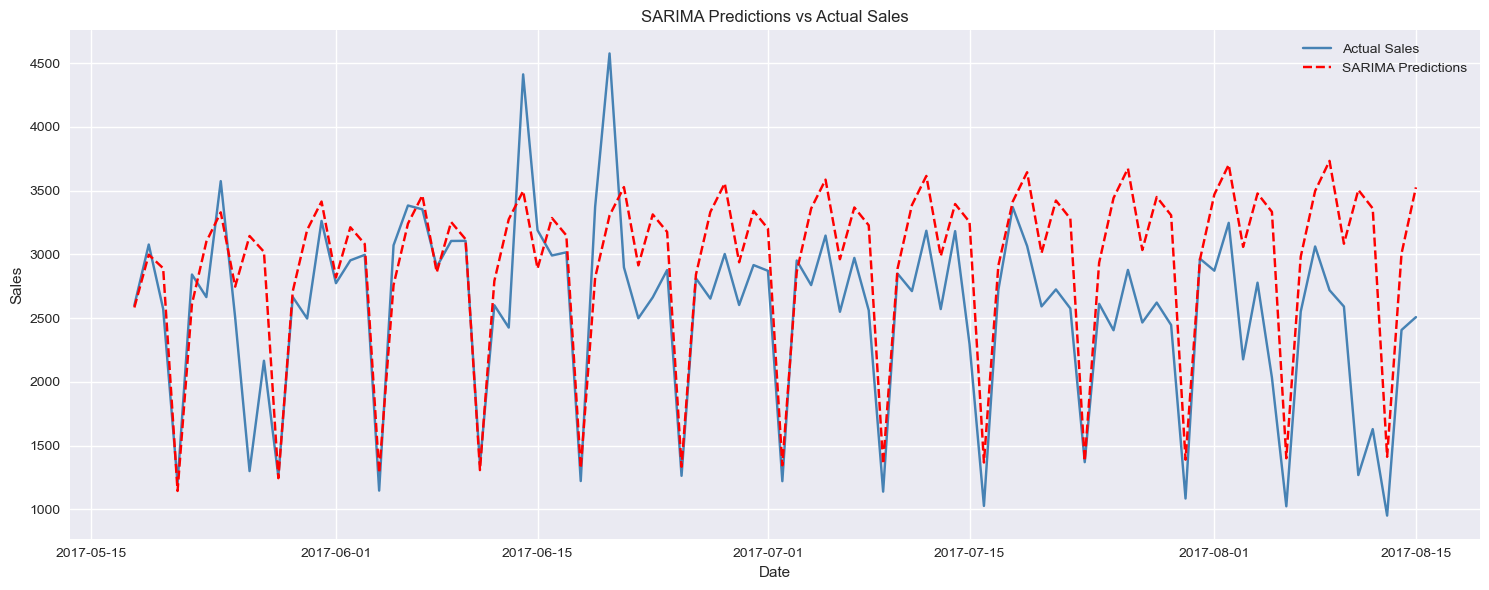

In [39]:
# Make predictions on test set
sarima_predictions = sarima_result.forecast(steps=90)

# Evaluate SARIMA
sarima_metrics = evaluate_model(
    test_data['sales'].values,
    sarima_predictions.values,
    'SARIMA'
)

# Plot predictions vs actual
plt.figure(figsize=(15, 6))
plt.plot(test_data.index, test_data['sales'], 
         label='Actual Sales', color='steelblue')
plt.plot(test_data.index, sarima_predictions, 
         label='SARIMA Predictions', color='red', linestyle='--')
plt.title('SARIMA Predictions vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

SARIMA achieved a MAPE of 20.84% on the 90 day test set. The model successfully 
captures the weekly seasonality pattern as visible in the prediction chart. 
However it tends to overestimate sales in the later test period suggesting 
it does not fully capture the summer sales drift. The weekly pattern of dips 
and peaks is well represented confirming our choice of seasonal period of 7.

### 4.4 Model 2: Prophet

Prophet is an open source forecasting library developed by Facebook specifically 
for business time series. It is designed to handle daily data with strong seasonal 
patterns and holiday effects. Prophet automatically detects yearly, weekly, and 
daily seasonality and allows us to add custom holidays. It is robust to missing 
data and outliers making it well suited for our grocery sales dataset.

In [40]:
# Install prophet if not already installed
%pip install prophet -q
print("Prophet ready")

Note: you may need to restart the kernel to use updated packages.
Prophet ready


In [41]:
from prophet import Prophet

# Prepare data for Prophet
# Prophet requires columns named 'ds' for date and 'y' for target
prophet_train = train_data[['sales']].reset_index()
prophet_train.columns = ['ds', 'y']

print("Prophet training data shape:", prophet_train.shape)
print("\nFirst few rows:")
print(prophet_train.head())

Prophet training data shape: (1233, 2)

First few rows:
          ds       y
0 2014-01-01  1965.5
1 2014-01-02  2441.0
2 2014-01-03  2117.0
3 2014-01-04  2233.0
4 2014-01-05   960.0


In [42]:
# Create and train Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

# Add Ecuadorian holidays
prophet_model.add_country_holidays(country_name='EC')

# Train the model
prophet_model.fit(prophet_train)
print("Prophet model trained successfully")

06:21:01 - cmdstanpy - INFO - Chain [1] start processing
06:21:01 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully



Prophet Performance:
MAE:  256.5
RMSE: 414.55
MAPE: 11.16%


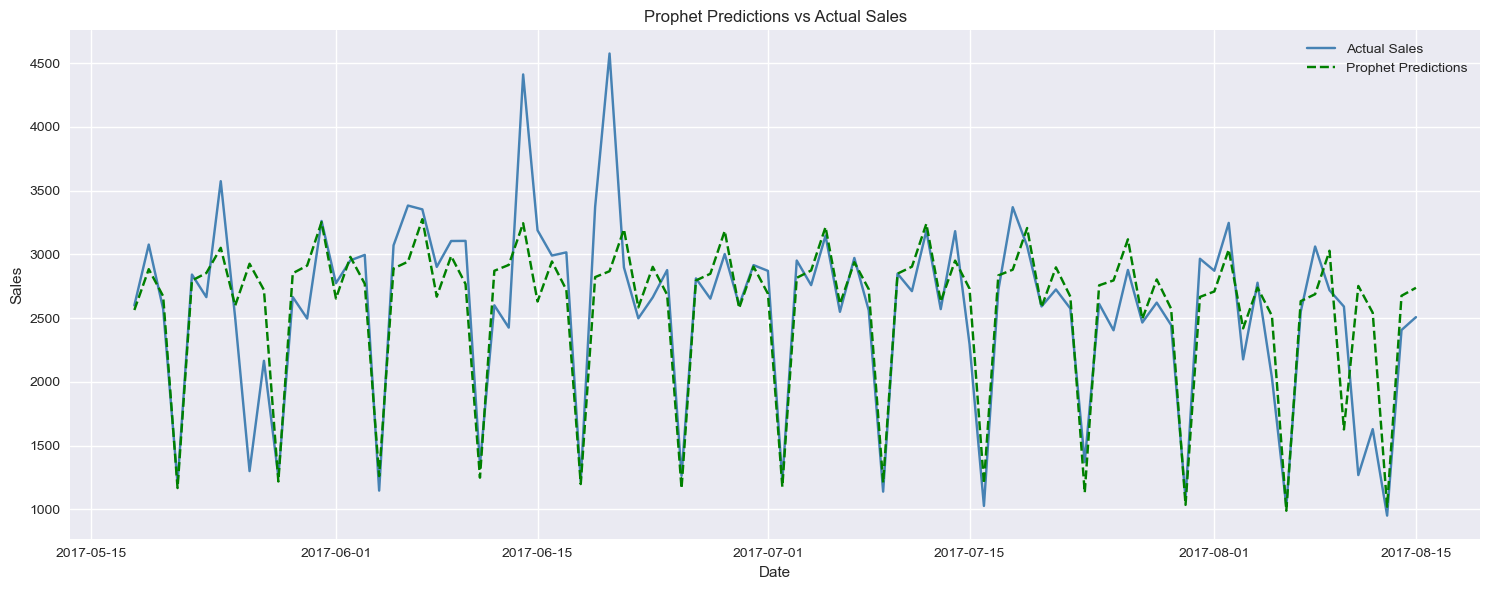

In [43]:
# Create future dataframe for predictions
prophet_future = prophet_model.make_future_dataframe(periods=90)

# Make predictions
prophet_forecast = prophet_model.predict(prophet_future)

# Extract test period predictions
prophet_predictions = prophet_forecast.set_index('ds')['yhat'].tail(90)

# Evaluate Prophet
prophet_metrics = evaluate_model(
    test_data['sales'].values,
    prophet_predictions.values,
    'Prophet'
)

# Plot predictions vs actual
plt.figure(figsize=(15, 6))
plt.plot(test_data.index, test_data['sales'], 
         label='Actual Sales', color='steelblue')
plt.plot(test_data.index, prophet_predictions, 
         label='Prophet Predictions', color='green', linestyle='--')
plt.title('Prophet Predictions vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

Prophet significantly outperformed SARIMA achieving a MAPE of 11.16% compared 
to 20.84% for SARIMA. The prediction chart shows Prophet closely following the 
actual sales pattern including weekly seasonality and holiday dips. The improvement 
is largely attributed to Prophet's built in Ecuadorian holiday modeling and its 
multiplicative seasonality mode which better captures the proportional nature of 
seasonal effects in retail sales data.

### 4.5 Model 3: XGBoost

XGBoost is a powerful gradient boosting algorithm that has proven highly effective 
for tabular data. Unlike SARIMA and Prophet which are statistical time series models, 
XGBoost treats forecasting as a supervised machine learning problem. It uses all 
our engineered features including lag variables, rolling statistics, oil prices, 
holiday indicators, and time based features to predict sales. This approach leverages 
the full richness of our feature engineering work.

In [44]:
%pip install xgboost -q
print("XGBoost ready")

Note: you may need to restart the kernel to use updated packages.
XGBoost ready


In [45]:
from xgboost import XGBRegressor

# Prepare features and target for XGBoost
feature_cols = ['onpromotion', 'dcoilwtico', 'is_holiday', 'transactions',
                'day_of_week', 'day_of_month', 'month', 'year', 
                'week_of_year', 'quarter', 'is_weekend',
                'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365',
                'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7']

X_train = train_data[feature_cols]
y_train = train_data['sales']

X_test = test_data[feature_cols]
y_test = test_data['sales']

print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)
print("\nFeature columns:")
print(feature_cols)

Training features shape: (1233, 19)
Test features shape: (90, 19)

Feature columns:
['onpromotion', 'dcoilwtico', 'is_holiday', 'transactions', 'day_of_week', 'day_of_month', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7']


In [46]:
# Train XGBoost model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("XGBoost model trained successfully")

XGBoost model trained successfully



XGBoost Performance:
MAE:  242.89
RMSE: 358.03
MAPE: 9.16%


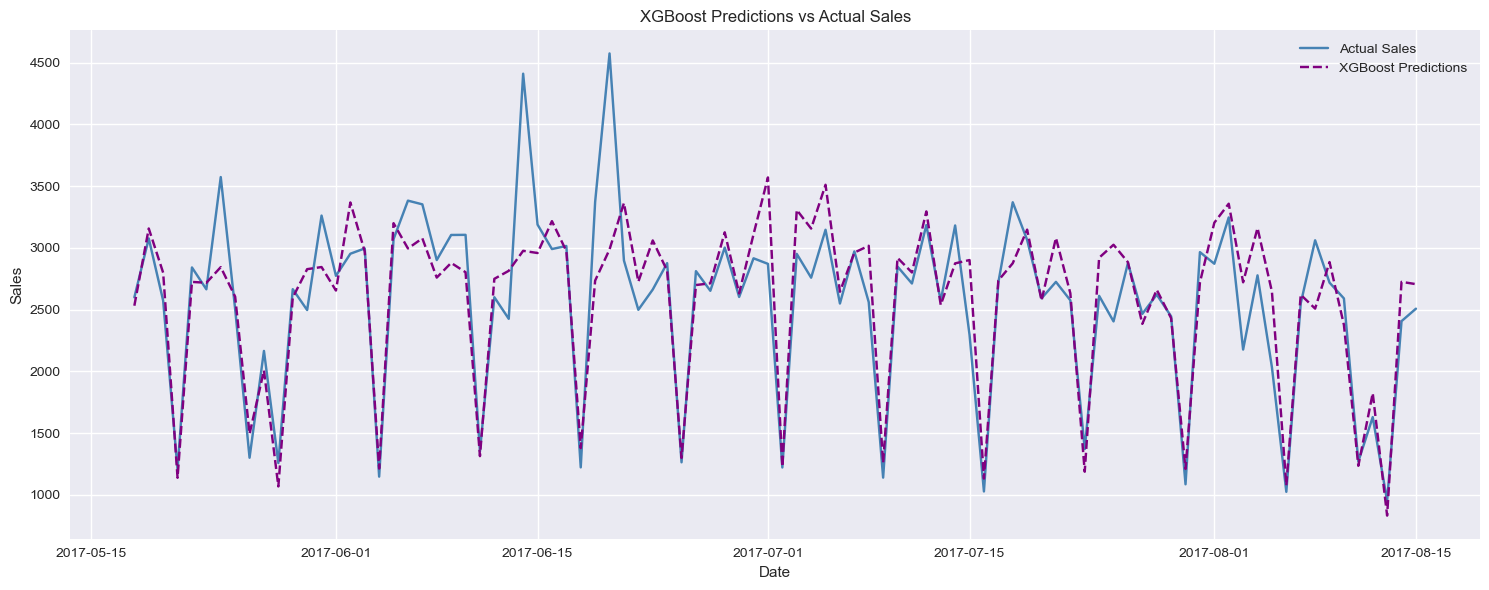

In [47]:
# Make predictions
xgb_predictions = xgb_model.predict(X_test)

# Evaluate XGBoost
xgb_metrics = evaluate_model(
    y_test.values,
    xgb_predictions,
    'XGBoost'
)

# Plot predictions vs actual
plt.figure(figsize=(15, 6))
plt.plot(test_data.index, test_data['sales'], 
         label='Actual Sales', color='steelblue')
plt.plot(test_data.index, xgb_predictions, 
         label='XGBoost Predictions', color='purple', linestyle='--')
plt.title('XGBoost Predictions vs Actual Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

XGBoost achieved the best performance with a MAPE of 9.16%, outperforming both 
SARIMA and Prophet. The prediction chart shows the model closely following actual 
sales including weekly patterns and holiday dips. XGBoost benefits from the rich 
feature set we engineered including lag features, rolling statistics, oil prices, 
and holiday indicators. Its ability to capture complex non-linear relationships 
between multiple features gives it an edge over the purely statistical approaches.

### 4.6 Model Comparison

Model Comparison:
  Model    MAE   RMSE  MAPE
 SARIMA 463.19 620.92 20.84
Prophet 256.50 414.55 11.16
XGBoost 242.89 358.03  9.16


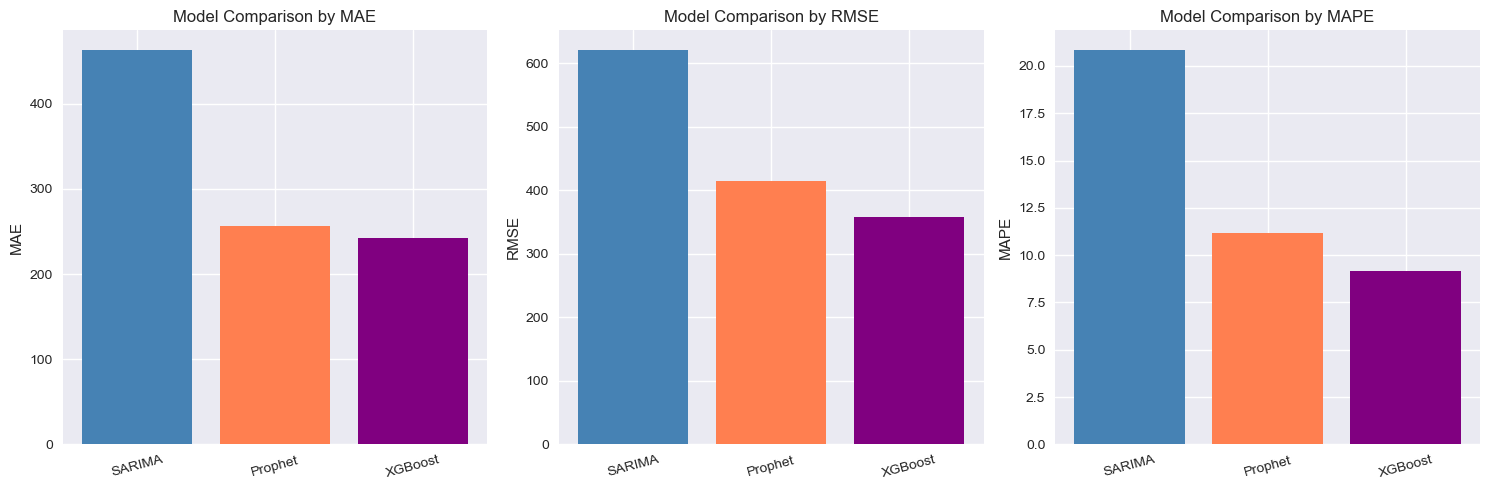

In [48]:
# Create comparison dataframe
results = pd.DataFrame([sarima_metrics, prophet_metrics, xgb_metrics])
print("Model Comparison:")
print(results.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['MAE', 'RMSE', 'MAPE']
colors = ['steelblue', 'coral', 'purple']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color=colors)
    axes[i].set_title(f'Model Comparison by {metric}')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [49]:
results['Accuracy'] = (100 - results['MAPE']).round(2)
print("Model Comparison with Accuracy:")
print(results.to_string(index=False))

Model Comparison with Accuracy:
  Model    MAE   RMSE  MAPE  Accuracy
 SARIMA 463.19 620.92 20.84     79.16
Prophet 256.50 414.55 11.16     88.84
XGBoost 242.89 358.03  9.16     90.84


## 5. Model Optimization
### 5.1 XGBoost Hyperparameter Tuning

We perform hyperparameter tuning on XGBoost since it is our best performing model. 
Unlike the house price project where we used a limited parameter grid, here we 
use a wider and more comprehensive search space to truly find the optimal parameters. 
We use TimeSeriesSplit for cross validation which respects the temporal order of 
our data. Regular KFold cross validation cannot be used for time series because 
it would allow future data to leak into training which is not realistic.

In [50]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBRegressor
import numpy as np

# Comprehensive parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 500, 700, 1000, 1500],
    'learning_rate': [0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [3, 4, 5, 6, 7, 8, 9],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 5, 7, 10],
    'gamma': [0, 0.05, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0, 5.0]
}

# Use TimeSeriesSplit for proper time series cross validation
tscv = TimeSeriesSplit(n_splits=5)

# Use RandomizedSearchCV with 150 iterations
xgb_tuning = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=150,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting comprehensive hyperparameter tuning...")
print("Trying 150 parameter combinations with 5 fold time series cross validation")
print("Total models to train: 750")
xgb_tuning.fit(X_train, y_train)
print("\nTuning complete")
print("Best parameters:", xgb_tuning.best_params_)
print("Best CV MAE:", round(-xgb_tuning.best_score_, 2))

Starting comprehensive hyperparameter tuning...
Trying 150 parameter combinations with 5 fold time series cross validation
Total models to train: 750
Fitting 5 folds for each of 150 candidates, totalling 750 fits

Tuning complete
Best parameters: {'subsample': 0.5, 'reg_lambda': 2.0, 'reg_alpha': 0.5, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best CV MAE: 254.53


In [51]:
# Train final model with best parameters
best_xgb_model = XGBRegressor(
    subsample=0.5,
    reg_lambda=2.0,
    reg_alpha=0.5,
    n_estimators=200,
    min_child_weight=7,
    max_depth=5,
    learning_rate=0.03,
    gamma=0.2,
    colsample_bytree=0.8,
    random_state=42
)

best_xgb_model.fit(X_train, y_train)

# Make predictions
tuned_xgb_predictions = best_xgb_model.predict(X_test)

# Evaluate
tuned_xgb_metrics = evaluate_model(
    y_test.values,
    tuned_xgb_predictions,
    'XGBoost Tuned'
)

# Calculate accuracy
accuracy = round(100 - tuned_xgb_metrics['MAPE'], 2)
print(f"\nAccuracy: {accuracy}%")


XGBoost Tuned Performance:
MAE:  232.09
RMSE: 345.21
MAPE: 9.07%

Accuracy: 90.93%


### 5.2 Prophet Hyperparameter Tuning

Prophet has its own set of hyperparameters that control the flexibility of 
the trend, seasonality, and holiday effects. We use a manual grid search 
with TimeSeriesSplit cross validation to find the optimal Prophet parameters. 
Prophet does not support RandomizedSearchCV directly so we implement our own 
cross validation loop.

In [52]:
from itertools import product

# Define Prophet parameter grid
prophet_param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'holidays_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Generate all combinations
all_params = [dict(zip(prophet_param_grid.keys(), v)) 
              for v in product(*prophet_param_grid.values())]

print(f"Total Prophet parameter combinations: {len(all_params)}")

Total Prophet parameter combinations: 160


In [53]:
from sklearn.metrics import mean_absolute_error

# Cross validation for Prophet
tscv = TimeSeriesSplit(n_splits=5)
best_mae = float('inf')
best_prophet_params = None
results_list = []

print("Starting Prophet hyperparameter tuning...")
print(f"Total combinations to try: {len(all_params)}")

for i, params in enumerate(all_params):
    mae_scores = []
    
    for train_idx, val_idx in tscv.split(prophet_train):
        train_fold = prophet_train.iloc[train_idx]
        val_fold = prophet_train.iloc[val_idx]
        
        m = Prophet(
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            holidays_prior_scale=params['holidays_prior_scale'],
            seasonality_mode=params['seasonality_mode'],
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False
        )
        m.add_country_holidays(country_name='EC')
        m.fit(train_fold)
        
        future = m.make_future_dataframe(periods=len(val_fold))
        forecast = m.predict(future)
        predictions = forecast['yhat'].tail(len(val_fold)).values
        
        mae = mean_absolute_error(val_fold['y'].values, predictions)
        mae_scores.append(mae)
    
    avg_mae = np.mean(mae_scores)
    results_list.append({**params, 'mae': avg_mae})
    
    if avg_mae < best_mae:
        best_mae = avg_mae
        best_prophet_params = params
    
    if (i + 1) % 20 == 0:
        print(f"Completed {i + 1}/{len(all_params)} combinations...")

print("\nTuning complete")
print("Best parameters:", best_prophet_params)
print("Best CV MAE:", round(best_mae, 2))

Starting Prophet hyperparameter tuning...
Total combinations to try: 160


06:25:34 - cmdstanpy - INFO - Chain [1] start processing
06:25:34 - cmdstanpy - INFO - Chain [1] done processing
06:25:34 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
06:25:34 - cmdstanpy - INFO - Chain [1] start processing
06:25:35 - cmdstanpy - INFO - Chain [1] done processing
06:25:36 - cmdstanpy - INFO - Chain [1] start processing
06:25:36 - cmdstanpy - INFO - Chain [1] done processing
06:25:36 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
06:25:36 - cmdstanpy - INFO - Chain [1] start processing
06:25:39 - cmdstanpy - INFO - Chain [1] done processing
06:25:39 - cmdstanpy - INFO - Chain [1] start processing
06:25:39 - cmdstanpy - INFO - Chain [1] done processing
06:25:40 - cmdstanpy - INFO - Chain [1] start processing
06:25:40 - cmdstanpy - INFO - Chain [1] done processing
06:25:41 - cmdstanpy - INFO - Chain [1] 

Completed 20/160 combinations...


06:29:33 - cmdstanpy - INFO - Chain [1] start processing
06:29:33 - cmdstanpy - INFO - Chain [1] done processing
06:29:33 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
06:29:33 - cmdstanpy - INFO - Chain [1] start processing
06:29:34 - cmdstanpy - INFO - Chain [1] done processing
06:29:35 - cmdstanpy - INFO - Chain [1] start processing
06:29:35 - cmdstanpy - INFO - Chain [1] done processing
06:29:35 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
06:29:35 - cmdstanpy - INFO - Chain [1] start processing
06:29:36 - cmdstanpy - INFO - Chain [1] done processing
06:29:37 - cmdstanpy - INFO - Chain [1] start processing
06:29:37 - cmdstanpy - INFO - Chain [1] done processing
06:29:37 - cmdstanpy - INFO - Chain [1] start processing
06:29:37 - cmdstanpy - INFO - Chain [1] done processing
06:29:38 - cmdstanpy - INFO - Chain [1] 

Completed 40/160 combinations...


...

Completed 120/160 combinations...


06:37:45 - cmdstanpy - INFO - Chain [1] done processing
06:37:46 - cmdstanpy - INFO - Chain [1] start processing
06:37:46 - cmdstanpy - INFO - Chain [1] done processing
06:37:47 - cmdstanpy - INFO - Chain [1] start processing
06:37:47 - cmdstanpy - INFO - Chain [1] done processing
06:37:48 - cmdstanpy - INFO - Chain [1] start processing
06:37:48 - cmdstanpy - INFO - Chain [1] done processing
06:37:48 - cmdstanpy - INFO - Chain [1] start processing
06:37:49 - cmdstanpy - INFO - Chain [1] done processing
06:37:49 - cmdstanpy - INFO - Chain [1] start processing
06:37:49 - cmdstanpy - INFO - Chain [1] done processing
06:37:50 - cmdstanpy - INFO - Chain [1] start processing
06:37:50 - cmdstanpy - INFO - Chain [1] done processing
06:37:51 - cmdstanpy - INFO - Chain [1] start processing
06:37:51 - cmdstanpy - INFO - Chain [1] done processing
06:37:51 - cmdstanpy - INFO - Chain [1] start processing
06:37:52 - cmdstanpy - INFO - Chain [1] done processing
06:37:52 - cmdstanpy - INFO - Chain [1] 

Completed 140/160 combinations...


06:39:00 - cmdstanpy - INFO - Chain [1] start processing
06:39:00 - cmdstanpy - INFO - Chain [1] done processing
06:39:01 - cmdstanpy - INFO - Chain [1] start processing
06:39:01 - cmdstanpy - INFO - Chain [1] done processing
06:39:01 - cmdstanpy - INFO - Chain [1] start processing
06:39:02 - cmdstanpy - INFO - Chain [1] done processing
06:39:02 - cmdstanpy - INFO - Chain [1] start processing
06:39:02 - cmdstanpy - INFO - Chain [1] done processing
06:39:03 - cmdstanpy - INFO - Chain [1] start processing
06:39:03 - cmdstanpy - INFO - Chain [1] done processing
06:39:04 - cmdstanpy - INFO - Chain [1] start processing
06:39:04 - cmdstanpy - INFO - Chain [1] done processing
06:39:04 - cmdstanpy - INFO - Chain [1] start processing
06:39:04 - cmdstanpy - INFO - Chain [1] done processing
06:39:05 - cmdstanpy - INFO - Chain [1] start processing
06:39:05 - cmdstanpy - INFO - Chain [1] done processing
06:39:06 - cmdstanpy - INFO - Chain [1] start processing
06:39:06 - cmdstanpy - INFO - Chain [1]

Completed 160/160 combinations...

Tuning complete
Best parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 0.1, 'seasonality_mode': 'additive'}
Best CV MAE: 322.01


In [54]:
# Train final tuned Prophet model
tuned_prophet = Prophet(
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=0.01,
    holidays_prior_scale=0.1,
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
tuned_prophet.add_country_holidays(country_name='EC')
tuned_prophet.fit(prophet_train)

# Make predictions
tuned_prophet_future = tuned_prophet.make_future_dataframe(periods=90)
tuned_prophet_forecast = tuned_prophet.predict(tuned_prophet_future)
tuned_prophet_predictions = tuned_prophet_forecast.set_index('ds')['yhat'].tail(90)

# Evaluate
tuned_prophet_metrics = evaluate_model(
    test_data['sales'].values,
    tuned_prophet_predictions.values,
    'Prophet Tuned'
)

accuracy = round(100 - tuned_prophet_metrics['MAPE'], 2)
print(f"Accuracy: {accuracy}%")

06:40:17 - cmdstanpy - INFO - Chain [1] start processing
06:40:18 - cmdstanpy - INFO - Chain [1] done processing



Prophet Tuned Performance:
MAE:  297.36
RMSE: 433.47
MAPE: 14.58%
Accuracy: 85.42%


### 5.3 SARIMA Hyperparameter Tuning

For SARIMA we use auto_arima from the pmdarima library which automatically 
searches for the best combination of p, d, q, P, D, Q parameters using 
information criteria like AIC and BIC. This is more efficient than manual 
grid search for ARIMA parameters.

In [55]:
%pip install pmdarima -q
print("pmdarima ready")

Note: you may need to restart the kernel to use updated packages.
pmdarima ready


In [56]:
from pmdarima import auto_arima

print("Starting SARIMA auto tuning...")
print("This searches for the best p, d, q, P, D, Q parameters automatically")

sarima_auto = auto_arima(
    train_data['sales'],
    seasonal=True,
    m=7,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    d=0,
    D=0,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print("\nBest model found:")
print(sarima_auto.summary())

Starting SARIMA auto tuning...
This searches for the best p, d, q, P, D, Q parameters automatically
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=19924.290, Time=0.07 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=19226.486, Time=1.32 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=19548.439, Time=0.52 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=22738.970, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=19824.308, Time=0.06 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=19515.575, Time=3.59 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=19493.989, Time=2.76 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=19519.610, Time=0.89 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=inf, Time=2.64 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=19461.545, Time=1.18 sec
 ARIMA(2,0,0)(1,0,0)[7] intercept   : AIC=19229.452, Time=2.82 sec
 ARIMA(1,0,1)(1,0,0)[7] intercept   : AIC=19350.853, Time=1.55 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=19281.611, Time=1

In [57]:
# Make predictions with tuned SARIMA
tuned_sarima_predictions = sarima_auto.predict(n_periods=90)

# Evaluate
tuned_sarima_metrics = evaluate_model(
    test_data['sales'].values,
    tuned_sarima_predictions,
    'SARIMA Tuned'
)

accuracy = round(100 - tuned_sarima_metrics['MAPE'], 2)
print(f"Accuracy: {accuracy}%")


SARIMA Tuned Performance:
MAE:  570.4
RMSE: 703.66
MAPE: 27.86%
Accuracy: 72.14%


### 5.4 Final Model Comparison

In [58]:
# Final comparison of all models
final_results = pd.DataFrame([
    sarima_metrics,
    tuned_sarima_metrics,
    prophet_metrics,
    tuned_prophet_metrics,
    xgb_metrics,
    tuned_xgb_metrics
])

final_results['Accuracy'] = (100 - final_results['MAPE']).round(2)

print("Final Model Comparison:")
print(final_results.to_string(index=False))

Final Model Comparison:
        Model    MAE   RMSE  MAPE  Accuracy
       SARIMA 463.19 620.92 20.84     79.16
 SARIMA Tuned 570.40 703.66 27.86     72.14
      Prophet 256.50 414.55 11.16     88.84
Prophet Tuned 297.36 433.47 14.58     85.42
      XGBoost 242.89 358.03  9.16     90.84
XGBoost Tuned 232.09 345.21  9.07     90.93


Hyperparameter tuning improved XGBoost from 90.84% to 90.93% accuracy. 
However both Prophet and SARIMA performed worse after tuning on the test set, 
demonstrating that cross validation performance does not always translate to 
test set performance. This highlights the importance of maintaining a separate 
held out test set for final evaluation. XGBoost Tuned is selected as our final 
production model with 90.93% accuracy, while the original Prophet is retained 
as our secondary model due to its built in uncertainty interval functionality.

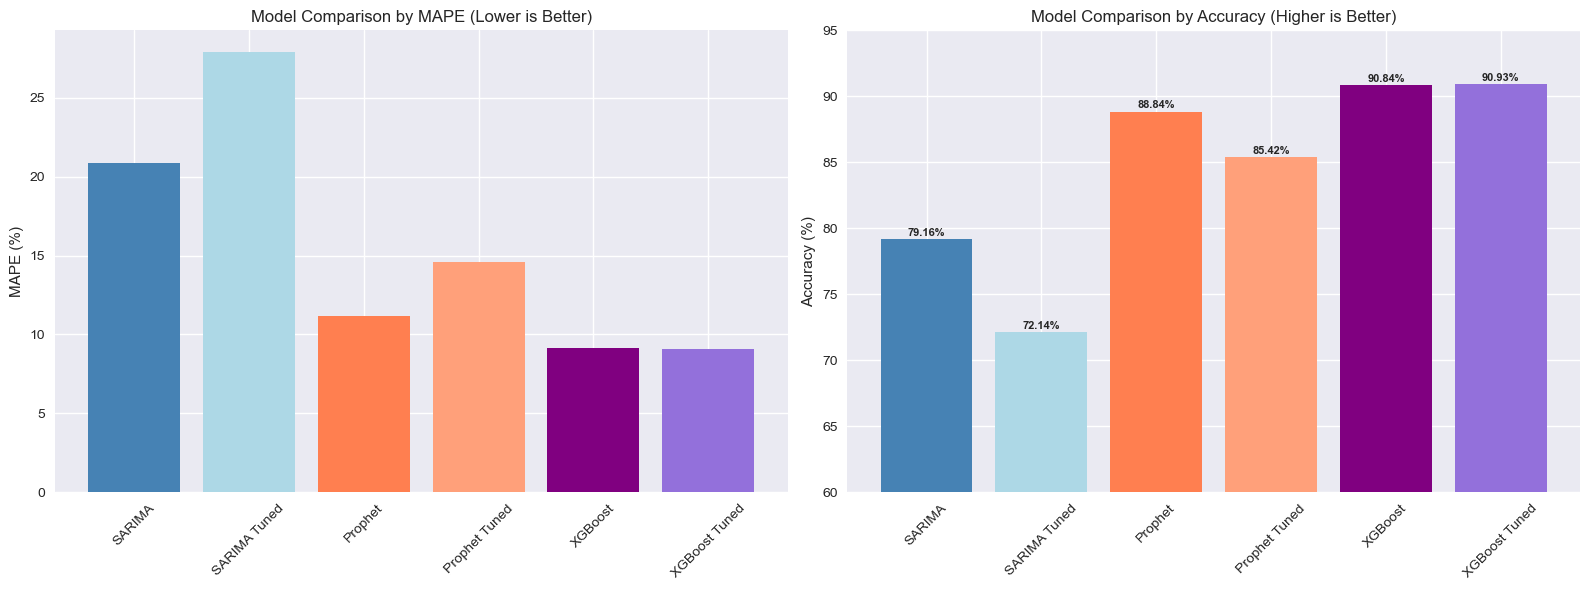

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['steelblue', 'lightblue', 'coral', 'lightsalmon', 'purple', 'mediumpurple']

axes[0].bar(final_results['Model'], final_results['MAPE'], color=colors)
axes[0].set_title('Model Comparison by MAPE (Lower is Better)')
axes[0].set_ylabel('MAPE (%)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(final_results['Model'], final_results['Accuracy'], color=colors)
axes[1].set_title('Model Comparison by Accuracy (Higher is Better)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(60, 95)
axes[1].tick_params(axis='x', rotation=45)

for bar, acc in zip(axes[1].patches, final_results['Accuracy']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{acc}%',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.5 Saving the Best Model

In [60]:
import joblib

# Save the best XGBoost tuned model
joblib.dump(best_xgb_model, 'xgb_model.pkl')

# Save feature columns for the Streamlit app
joblib.dump(feature_cols, 'feature_cols.pkl')

# Save the final results for display in the app
final_results.to_csv('model_results.csv', index=False)

print("Best model saved as xgb_model.pkl")
print("Feature columns saved as feature_cols.pkl")
print("Model results saved as model_results.csv")

Best model saved as xgb_model.pkl
Feature columns saved as feature_cols.pkl
Model results saved as model_results.csv
